# Produce a short EDA report - Task 5
This program will produce a presentable report using findings from Task #2 and Task #3.

In [6]:
import pandas as pd
import numpy as np
import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import matplotlib.pyplot as plt
import seaborn as sns

pd.read_parquet() resolves the relative path from the notebook kernel’s current working directory, which may differ from the folder containing your notebook. So Python may be looking for doha_parsed_cases in the wrong location.

In [7]:

from pathlib import Path

print("Current working directory:", Path.cwd())
print("Expected file path:", (Path.cwd() / "doha_parsed_cases" / "all_cases_1.parquet").resolve())
print("Folder exists:", (Path.cwd() / "doha_parsed_cases").is_dir())

Current working directory: c:\Users\elead\OneDrive\Desktop\Python-VSC-Workspace\A3-Consulting-1C-adjudicative-guidelines-analyzer
Expected file path: C:\Users\elead\OneDrive\Desktop\Python-VSC-Workspace\A3-Consulting-1C-adjudicative-guidelines-analyzer\doha_parsed_cases\all_cases_1.parquet
Folder exists: False


# Task #2: EDA - Key Findings 

If the folder is elsewhere, use its full path, or change the working directory to the project folder before loading:

In [8]:
from pathlib import Path
import os

project_dir = Path(r"C:\Users\elead\OneDrive\Desktop\Python-VSC-Workspace\doha")
os.chdir(project_dir)

df1 = pd.read_parquet("doha_parsed_cases/all_cases_1.parquet")
df2 = pd.read_parquet("doha_parsed_cases/all_cases_2.parquet")

In [9]:

print("Columns in dataset 1 are: " + str(df1.columns.tolist()))
print("Dataset 1 first 10 rows:" + str(df1.head(10)))
print("Dataset 1 types are: " + str(df1.dtypes))

Columns in dataset 1 are: ['case_number', 'date', 'outcome', 'guidelines', 'summary', 'full_text', 'sor_allegations', 'mitigating_factors', 'judge', 'source_url', 'formal_findings', 'case_type', 'appeal_board_members', 'who_appealed', 'judges_findings_of_fact', 'judges_analysis', 'discussion', 'order']
Dataset 1 first 10 rows:  case_number               date  outcome guidelines  \
0    03-16936     August 2, 2007   DENIED        [G]   
1    03-17061     March 16, 2007   DENIED     [E, J]   
2    03-11420      June 13, 2007   DENIED        [B]   
3    03-08231    October 9, 2007   DENIED        [E]   
4    03-20320  December 12, 2007   DENIED     [D, J]   
5    03-21190     March 12, 2007  UNKNOWN     [B, C]   
6    03-08257       May 16, 2008   DENIED  [A, E, K]   
7    03-21688       July 2, 2007   DENIED  [E, K, M]   
8    03-21262         07/10/2007   DENIED  [B, E, J]   
9    03-21497      July 30, 2009   DENIED     [E, F]   

                                             summary  \

In [10]:
print("Dataset 1 outcome value counts are: " + str(df1["outcome"].value_counts()))
print("Dataset 1 outcome value counts normalized are: " + str(df1["outcome"].value_counts(normalize=True)))

Dataset 1 outcome value counts are: outcome
DENIED      10604
GRANTED      6036
UNKNOWN       985
REMANDED      110
REVOKED         7
Name: count, dtype: int64
Dataset 1 outcome value counts normalized are: outcome
DENIED      0.597678
GRANTED     0.340210
UNKNOWN     0.055518
REMANDED    0.006200
REVOKED     0.000395
Name: proportion, dtype: float64


In [11]:
print("Dataset 1 case type value counts are: " + str(df1["case_type"].value_counts()))
print("Dataset 1 case type value counts normalized are: " + str(df1["case_type"].value_counts(normalize=True)))

Dataset 1 case type value counts are: case_type
hearing    15372
appeal      2370
Name: count, dtype: int64
Dataset 1 case type value counts normalized are: case_type
hearing    0.866419
appeal     0.133581
Name: proportion, dtype: float64


In [12]:

print("Columns in dataset 2 are: " + str(df2.columns.tolist()))
print("Dataset 2 first 10 rows:" + str(df2.head(10)))
print("Dataset 2 types are: " + str(df2.dtypes))

Columns in dataset 2 are: ['case_number', 'date', 'outcome', 'guidelines', 'summary', 'full_text', 'sor_allegations', 'mitigating_factors', 'judge', 'source_url', 'formal_findings', 'case_type', 'appeal_board_members', 'who_appealed', 'judges_findings_of_fact', 'judges_analysis', 'discussion', 'order']
Dataset 2 first 10 rows:  case_number               date outcome guidelines  \
0    06-09542  September 4, 2007  DENIED     [B, C]   
1    06-09401     April 16, 2007  DENIED        [F]   
2    06-09643      June 22, 2009  DENIED  [E, J, M]   
3    06-09782      July 30, 2007  DENIED        [H]   
4    06-10859  September 2, 2010  DENIED     [E, G]   
5    06-10320   November 7, 2007  DENIED        [F]   
6    06-10663    October 3, 2007  DENIED        [F]   
7    06-10888     August 6, 2007  DENIED     [E, F]   
8    06-10890    August 28, 2007  DENIED     [E, F]   
9    06-10950      July 25, 2007  DENIED  [E, G, J]   

                                             summary  \
0  FOR OFF

In [13]:
print("Dataset 2 outcome value counts are: " + str(df2["outcome"].value_counts()))
print("Dataset 2 outcome value counts normalized are: " + str(df2["outcome"].value_counts(normalize=True)))

Dataset 2 outcome value counts are: outcome
DENIED      10480
GRANTED      3397
UNKNOWN      1749
REMANDED      234
REVOKED         8
Name: count, dtype: int64
Dataset 2 outcome value counts normalized are: outcome
DENIED      0.660449
GRANTED     0.214079
UNKNOWN     0.110222
REMANDED    0.014747
REVOKED     0.000504
Name: proportion, dtype: float64


In [14]:
print("Dataset 2 case type value counts are: " + str(df2["case_type"].value_counts()))
print("Dataset 2 case type value counts normalized are: " + str(df2["case_type"].value_counts(normalize=True)))

Dataset 2 case type value counts are: case_type
hearing    12601
appeal      3267
Name: count, dtype: int64
Dataset 2 case type value counts normalized are: case_type
hearing    0.794114
appeal     0.205886
Name: proportion, dtype: float64


# Outcome Distributions

- I decided to make bar charts for each dataframe to get a better visual of the disruption between different outcomes

In [15]:
class_distribution_df1 = df1["outcome"].value_counts(normalize = True)*100
display(class_distribution_df1)

outcome
DENIED      59.767783
GRANTED     34.020967
UNKNOWN      5.551798
REMANDED     0.619998
REVOKED      0.039454
Name: proportion, dtype: float64

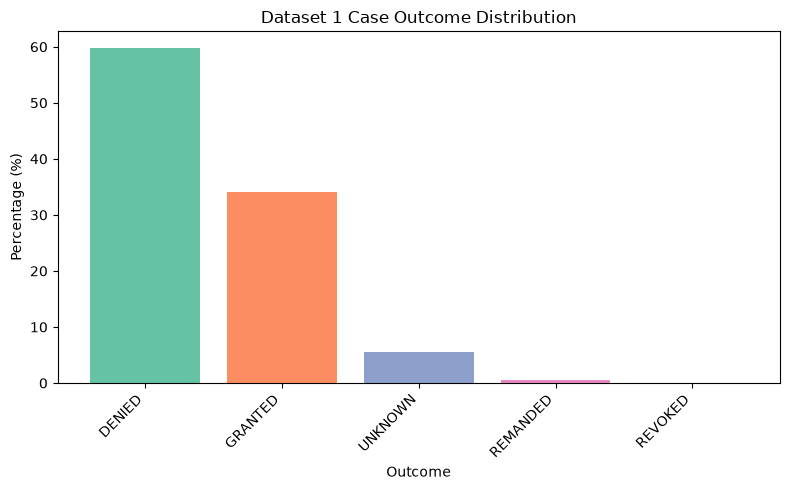

In [ ]:
#This is a visualization of the outcome distribution

# Create a bar chart
plt.figure(figsize=(8, 5))
plt.bar(
    class_distribution_df1.index.astype(str),
    class_distribution_df1.values,
    color=sns.color_palette("Set2", n_colors=len(class_distribution_df1)),
)
plt.xlabel("Outcome")
plt.ylabel("Percentage (%)")
plt.title("Dataset 1 Case Outcome Distribution")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [45]:
class_distribution_df2 = df2["outcome"].value_counts(normalize = True)*100
display(class_distribution_df2)

outcome
DENIED      66.044870
GRANTED     21.407865
UNKNOWN     11.022183
REMANDED     1.474666
REVOKED      0.050416
Name: proportion, dtype: float64

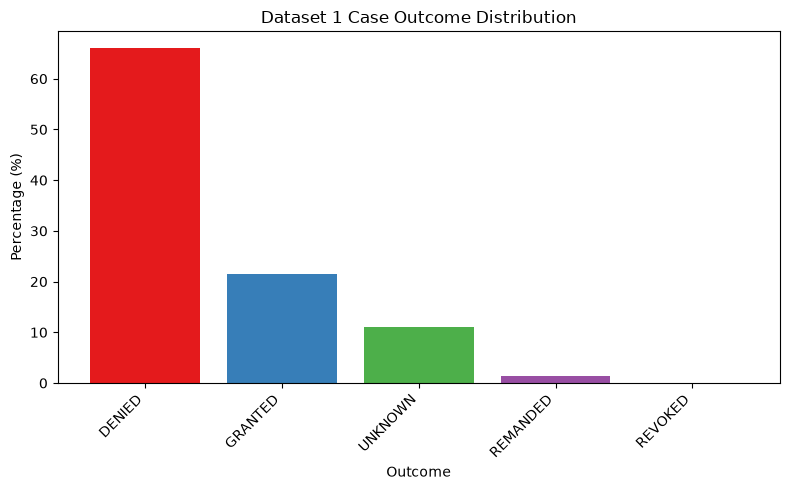

In [46]:
#This is a visualization of the outcome distribution

# Create a bar chart

plt.figure(figsize=(8, 5))
plt.bar(
    class_distribution_df2.index.astype(str),
    class_distribution_df2.values,
    color=sns.color_palette("Set1", n_colors=len(class_distribution_df2)),
)
plt.xlabel("Outcome")
plt.ylabel("Percentage (%)")
plt.title("Dataset 1 Case Outcome Distribution")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Task #3: TF-IDF algorithm - Key Findings

In [2]:
#import libraries
import sys
from pathlib import Path

import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Make the repo root importable so `from src.data_loader import load_cases` works
# regardless of where Jupyter was launched from.
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.data_loader import load_cases

In [3]:
# load the full merged dataset (both shards) via the shared loading pipeline.
# First run builds+caches data/processed/all_cases.parquet; later runs just read the cache.
df = load_cases()
print(df.shape)

[data_loader] Building cache from 2 raw shard(s) in 'C:\Users\elead\OneDrive\Desktop\Python-VSC-Workspace\doha\doha_parsed_cases':
  - all_cases_1.parquet: 17,742 rows
  - all_cases_2.parquet: 15,868 rows
[data_loader] Cached 33,610 rows x 20 cols -> 'C:\Users\elead\OneDrive\Desktop\Python-VSC-Workspace\A3-Consulting-1C-adjudicative-guidelines-analyzer\data\processed\all_cases.parquet'
(33610, 20)


In [4]:
# drop any rows missing full_text/outcome (currently a no-op safety guard, not a cleaning
# pass -- see markdown note below)
df = df.dropna(subset=['full_text', 'outcome']).sample(frac=1, random_state=42)

# randomize, and take a 2000-case sample for this baseline (Izzy's original version only saw 2k)
df = df.head(2000)
print(df.shape)
print(df['outcome'].value_counts())


(2000, 20)
outcome
DENIED      1263
GRANTED      536
UNKNOWN      174
REMANDED      26
REVOKED        1
Name: count, dtype: int64


In [37]:
# split the text into training and validation sets
# NOTE: no stratify= here -- see markdown note above re: rare outcome classes (e.g. REVOKED)
X_train, X_val, y_train, y_val = train_test_split(
    df['full_text'], 
    df['outcome'], 
    test_size=0.2, 
    random_state=42,
)

print("Training cases:", len(X_train))
print("Validation cases:", len(X_val))

Training cases: 1600
Validation cases: 400


In [38]:
# create a TF-IDF vectorizer
vec = TfidfVectorizer(max_features=2000, ngram_range=(1, 2))

Xtr = vec.fit_transform(X_train) #x training data
Xv = vec.transform(X_val)   # x validation data

print("Training TF-IDF shape:", Xtr.shape)
print("Validation TF-IDF shape:", Xv.shape)

Training TF-IDF shape: (1600, 2000)
Validation TF-IDF shape: (400, 2000)


# Task 5: Short EDA report using findings from Task #2 and Task #3

- I plan to use the most occuring words in the training data to find possible relationships/correlation to the case outcomes

In [ ]:
#Top 50 words in the X_train dataset:

from collections import Counter

analyze = vec.build_analyzer()
word_counts = Counter(
    term
    for text in X_train
    for term in analyze(text)
    if " " not in term and term in vec.vocabulary_
)

top_words = pd.DataFrame(
    word_counts.most_common(50),
    columns=["word", "count"],
)
display(top_words)

,word,count
0,the,244385
1,of,125042
2,to,120488
3,and,113059
4,applicant,94367
5,in,91677
6,he,56389
7,his,54795
8,for,53638
9,that,51996


In [41]:
#I will now narrow these words down to the top 10:

top_words = pd.DataFrame(
    word_counts.most_common(10),
    columns=["word", "count"],
)
display(top_words)

,word,count
0,the,244385
1,of,125042
2,to,120488
3,and,113059
4,applicant,94367
5,in,91677
6,he,56389
7,his,54795
8,for,53638
9,that,51996


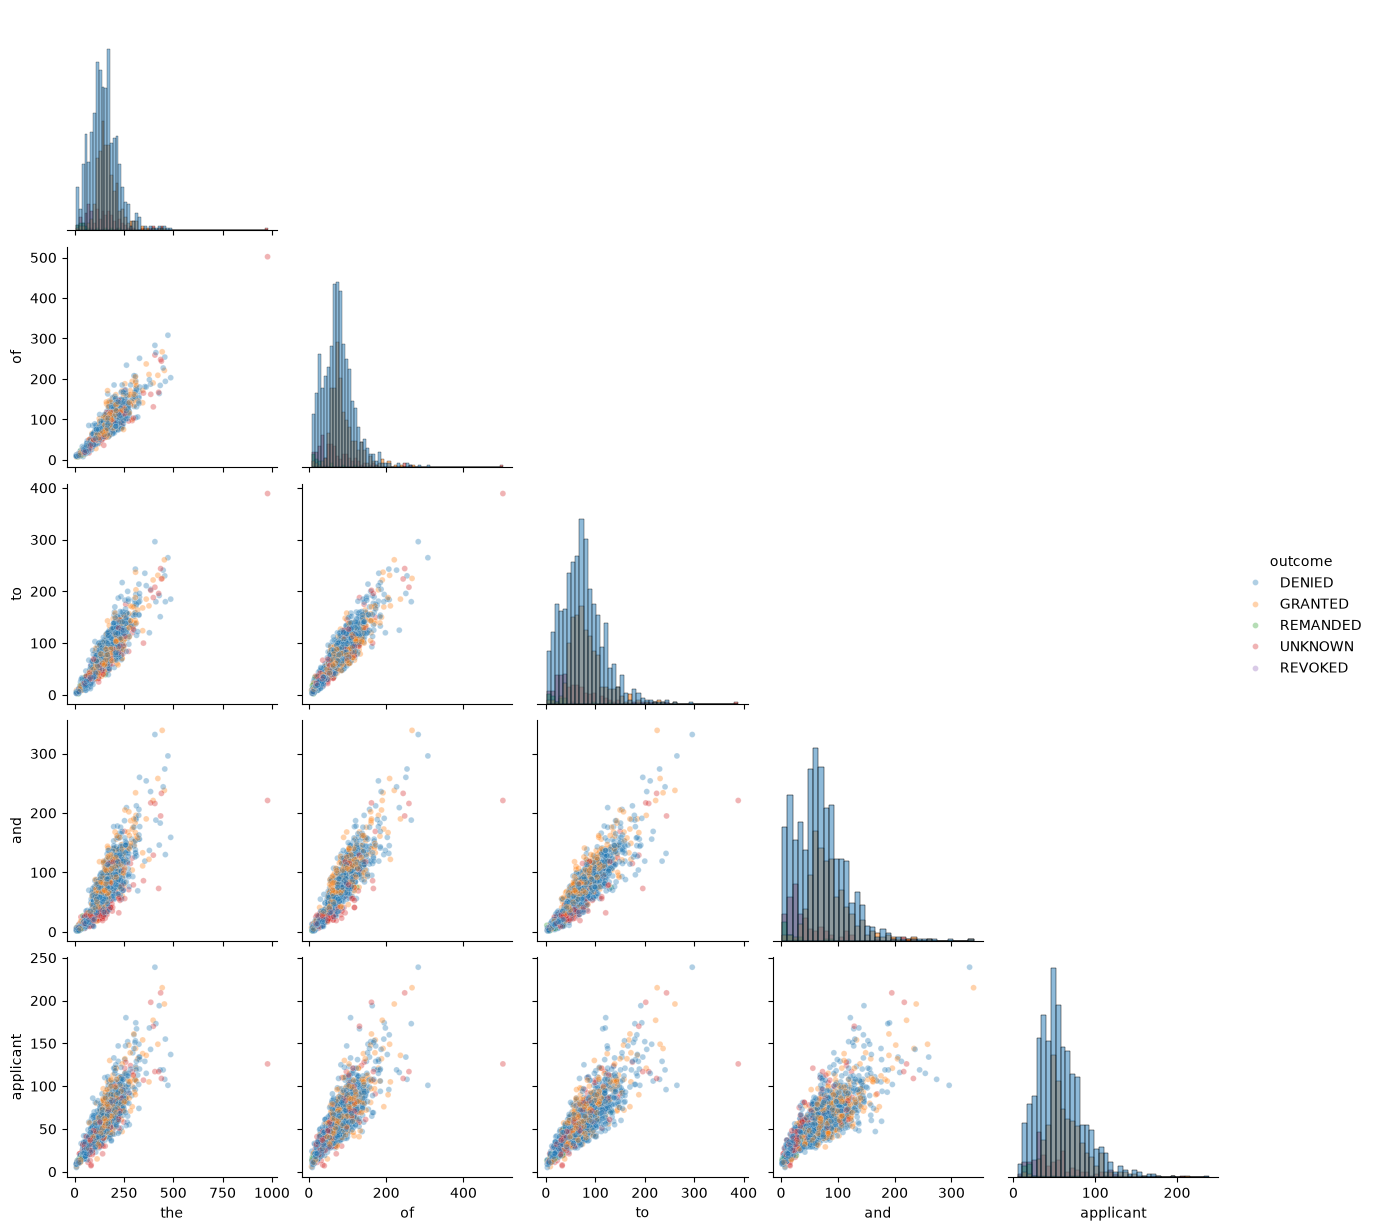

In [42]:
#With these top ten words, I will create a seaborn pairplot to visualize its relationships to the outcomes in the cases they are associated with:

from sklearn.feature_extraction.text import CountVectorizer

top_terms = top_words["word"].head(5).tolist()

plot_cases = (
    df[["full_text", "outcome"]]
    .dropna(subset=["full_text", "outcome"])
    .sample(n=min(1500, len(df)), random_state=42)
)

count_vectorizer = CountVectorizer(vocabulary=top_terms)
word_counts = count_vectorizer.fit_transform(plot_cases["full_text"])

pairplot_data = pd.DataFrame(
    word_counts.toarray(),
    columns=top_terms,
    index=plot_cases.index,
)
pairplot_data["outcome"] = plot_cases["outcome"].astype(str)

sns.pairplot(
    pairplot_data,
    vars=top_terms,
    hue="outcome",
    diag_kind="hist",
    corner=True,
    plot_kws={"alpha": 0.35, "s": 18},
)
plt.show()

Based on the pair plot above, the most occurring words don't have much effect on the outcome, due to the fact that the words are irrelevant words such as "the" and "of". In order to get words that are actually relevant, i'll use a short logistic regression model to find words in the vec that are actually affiliated with the outcomes:

In [ ]:
# 1. Train the classifier: It learns how the TF-IDF word features relate to the outcomes in y_train.
model_compare = LogisticRegression(max_iter=1000)
model_compare.fit(Xtr, y_train)

# 2. Get the feature names: This gives the word and phrase labels for the columns in Xtr.
feature_names = vec.get_feature_names_out()
# 3. Choose how many words to show: The code will show the 20 strongest terms for each outcome.
top_n = 20

# 4. Get coefficients for each outcome: 
#Logistic regression assigns each term a coefficient. A higher positive coefficient means the term is more associated with that outcome. 
#The special if block handles binary classification, where scikit-learn stores just one coefficient row for two outcomes.
# Handle binary classifiers, whose coefficient array has one row for two classes.
if len(model_compare.classes_) == 2 and model_compare.coef_.shape[0] == 1:
    class_coefficients = [
        (model_compare.classes_[1], model_compare.coef_[0]),
        (model_compare.classes_[0], -model_compare.coef_[0]),
    ]
else:
    class_coefficients = zip(model_compare.classes_, model_compare.coef_)

for outcome, coefficients in class_coefficients:

# 5. Rank and display the terms: This finds the indices of the 20 largest coefficients, ordered from highest to lowest. 
# The following DataFrame displays each term beside its coefficient.
    top_indices = np.argsort(coefficients)[-top_n:][::-1]
    print(f"\nWords most associated with {outcome}:")
    display(pd.DataFrame({
        "word": feature_names[top_indices],
        "coefficient": coefficients[top_indices],
    }))


Words most associated with DENIED:


,word,coefficient
0,against,2.929354
1,against applicant,2.666755
2,not,2.179098
3,subparagraph against,2.030097
4,is denied,1.803647
5,denied,1.457745
6,has not,1.250553
7,he,1.163258
8,against the,1.139397
9,guideline against,1.113379



Words most associated with GRANTED:


,word,coefficient
0,and,2.365152
1,is granted,2.278788
2,for,1.730720
3,ae,1.670501
4,for applicant,1.382732
5,granted,1.242752
6,subparagraph for,1.163527
7,guideline for,1.050386
8,tr,0.984662
9,is clearly,0.971805



Words most associated with REMANDED:


,word,coefficient
0,the judge,1.623128
1,we,1.165835
2,appeal,0.911714
3,james,0.881920
4,judge,0.880981
5,decision,0.550082
6,appeal board,0.518800
7,to the,0.510683
8,that,0.492497
9,interview,0.470545



Words most associated with UNKNOWN:


,word,coefficient
0,the administrative,1.867975
1,the board,1.543581
2,a1,1.444718
3,judge,1.306234
4,administrative,1.287483
5,administrative judge,1.239031
6,board,1.074339
7,html,0.848209
8,doha,0.834765
9,record evidence,0.792617


Please Note: The results are model associations, not proof that a word causes an outcome. Because the  vectorizer uses ngram_range=(1, 2), the results can include both single words and two-word phrases.